Epoch 1 Loss = 1.2006 Accuracy = 0.35
Epoch 11 Loss = 1.1299 Accuracy = 0.32
Epoch 21 Loss = 1.1213 Accuracy = 0.33
Epoch 31 Loss = 1.1158 Accuracy = 0.33
Epoch 41 Loss = 1.1120 Accuracy = 0.34
Epoch 51 Loss = 1.1093 Accuracy = 0.34
Epoch 61 Loss = 1.1074 Accuracy = 0.33
Epoch 71 Loss = 1.1059 Accuracy = 0.34
Epoch 81 Loss = 1.1047 Accuracy = 0.33
Epoch 91 Loss = 1.1038 Accuracy = 0.33


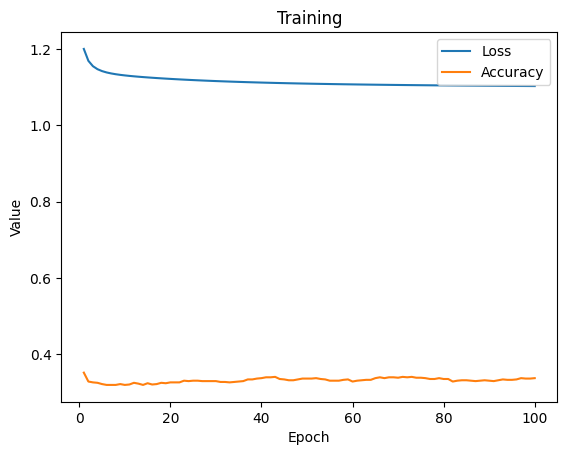

Accuracy  : 0.3600
Precision : 0.3663
Recall    : 0.3391
F1 Score  : 0.3167


In [42]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=5000, precision=3)
# Softmax output

# W = (neurons, features)
# X = (features, samples)

def act(Z, t):
    if t == 'relu': return np.maximum(0, Z)
    if t == 'sigmoid': return 1 / (1 + np.exp(-Z))
    if t == 'tanh': return np.tanh(Z)

def act_d(A, t):
    if t == 'relu': return (A > 0).astype(float)
    if t == 'sigmoid': return A * (1 - A)
    if t == 'tanh': return 1 - A**2

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)



def init(layers):
    n,h1,h2,c = layers
    W1 = np.random.randn(h1, n) * np.sqrt(2/n)
    b1 = np.zeros((h1,1))
    W2 = np.random.randn(h2,h1) * np.sqrt(2/h1)
    b2 = np.zeros((h2,1))
    W3 = np.random.randn(c,h2) * np.sqrt(2/h2)
    b3 = np.zeros((c,1))
    return [W1,b1,W2,b2,W3,b3]



def one_hot(y, num_classes):
    # output shape = (classes, samples)
    y_oh = np.zeros((num_classes, len(y)))
    y_oh[y, np.arange(len(y))] = 1
    return y_oh



def forward(X, params, act1, act2):
    W1,b1,W2,b2,W3,b3 = params

    Z1 = W1 @ X + b1
    A1 = act(Z1, act1)
    Z2 = W2 @ A1 + b2
    A2 = act(Z2, act2)
    Z3 = W3 @ A2 + b3
    A3 = softmax(Z3)
    return A3, (A1,A2,A3)



def compute_loss(y_oh,y_pred):
    m = y_oh.shape[1]
    return -np.sum(y_oh * np.log(y_pred + 1e-8)) / m



def backward(X, y_oh, params, cache, act1, act2):
    W1,b1,W2,b2,W3,b3 = params
    A1,A2,A3 = cache

    m = X.shape[1]

    dZ3 = A3 - y_oh
    dW3 = dZ3 @ A2.T / m
    db3 = np.sum(dZ3, axis=1, keepdims=True) / m

    dZ2 = (W3.T @ dZ3) * act_d(A2, act2)
    dW2 = dZ2 @ A1.T / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = (W2.T @ dZ2) * act_d(A1, act1)
    dW1 = dZ1 @ X.T / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return [dW1,db1,dW2,db2,dW3,db3]



def update(params, grads, lr):
    W1,b1,W2,b2,W3,b3 = params
    dW1,db1,dW2,db2,dW3,db3 = grads

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3
    return [W1,b1,W2,b2,W3,b3]



def train(X, y,layers, epochs=50, lr=0.1, act1='relu', act2='relu'):
    params = init(layers)
    y_oh = one_hot(y, layers[-1])
    loss = []
    acc = []

    for i in range(epochs):
        y_pred, cache = forward(X, params, act1, act2)
        l = compute_loss(y_oh,y_pred)
        grads = backward(X, y_oh, params,cache, act1, act2)
        params = update(params, grads, lr)

        a = accuracy(y,y_pred)
        acc.append(a)
        loss.append(l)

        if i%10==0:
          print(f"Epoch {i+1} Loss = {l:.4f} Accuracy = {a:.2f}")

    return params,loss,acc


def accuracy(y,y_pred):
  preds = np.argmax(y_pred,axis=0)
  return np.mean(y == preds)



def evaluate(X, y, params, act1, act2):
    y_pred, _ = forward(X, params, act1, act2)
    preds = np.argmax(y_pred, axis=0)
    return preds



def metrics(y_true, y_pred, num_classes):
    accuracy = np.mean(y_true == y_pred)
    precision_list = []
    recall_list = []
    f1_list = []

    for c in range(num_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    return (
        accuracy,
        np.mean(precision_list),
        np.mean(recall_list),
        np.mean(f1_list)
    )





def plot_loss(loss,title):
    plt.plot(loss)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()


def plot_metrics(loss, acc, title="Training"):
      epochs = range(1, len(loss)+1)

      plt.plot(epochs, loss, label='Loss')
      plt.plot(epochs, acc, label='Accuracy')

      plt.title(title)
      plt.xlabel("Epoch")
      plt.ylabel("Value")
      plt.legend()
      plt.show()





# ---------------------------------------------------
# x = (features x samples)
X = np.random.randint(0,255,(20,1000))
y = np.random.randint(0,3,1000)
X = X / 255.0

X_train = X[:, 0:900]
y_train = y[0:900]

X_test = X[:, 900:1000]
y_test = y[900:1000]



# training
params, loss, acc = train(
    X_train,
    y_train,
    layers=[20,10,5,3],
    epochs=100,
    lr=0.1,
    act1='tanh',
    act2='tanh'
)

plot_metrics(loss, acc)

# testing
preds = evaluate(
    X_test,
    y_test,
    params,
    'tanh',
    'tanh'
)

acc, prec, rec, f1 = metrics(y_test, preds, 3)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")



Epoch 1 Loss = 1.2048 Accuracy = 0.30
Epoch 11 Loss = 1.0998 Accuracy = 0.34
Epoch 21 Loss = 1.0951 Accuracy = 0.34
Epoch 31 Loss = 1.0935 Accuracy = 0.36
Epoch 41 Loss = 1.0921 Accuracy = 0.37
Epoch 51 Loss = 1.0910 Accuracy = 0.37
Epoch 61 Loss = 1.0904 Accuracy = 0.37
Epoch 71 Loss = 1.0899 Accuracy = 0.37
Epoch 81 Loss = 1.0895 Accuracy = 0.38
Epoch 91 Loss = 1.0891 Accuracy = 0.38
Epoch 101 Loss = 1.0888 Accuracy = 0.38
Epoch 111 Loss = 1.0885 Accuracy = 0.38
Epoch 121 Loss = 1.0882 Accuracy = 0.38
Epoch 131 Loss = 1.0880 Accuracy = 0.38
Epoch 141 Loss = 1.0878 Accuracy = 0.38
Epoch 151 Loss = 1.0876 Accuracy = 0.38
Epoch 161 Loss = 1.0873 Accuracy = 0.38
Epoch 171 Loss = 1.0871 Accuracy = 0.38
Epoch 181 Loss = 1.0869 Accuracy = 0.38
Epoch 191 Loss = 1.0867 Accuracy = 0.38
Epoch 201 Loss = 1.0865 Accuracy = 0.38
Epoch 211 Loss = 1.0863 Accuracy = 0.38
Epoch 221 Loss = 1.0860 Accuracy = 0.38
Epoch 231 Loss = 1.0858 Accuracy = 0.38
Epoch 241 Loss = 1.0856 Accuracy = 0.39
Epoch 251 L

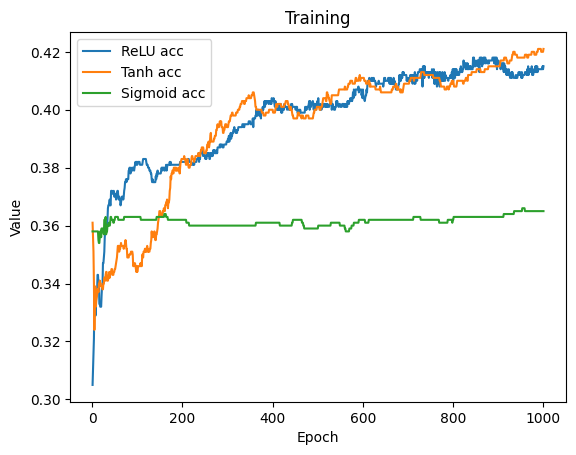

In [43]:

#-----------------------------------------
_,loss_r,acc_r= train(X, y,[20,10,5,3], 1000, 0.1, 'relu', 'relu')
_,loss_t,acc_t= train(X, y,[20,10,5,3], 1000, 0.1, 'tanh', 'tanh')
_,loss_s,acc_s= train(X, y,[20,10,5,3], 1000, 0.1, 'sigmoid', 'sigmoid')


epochs= range(1,len(loss_t)+1)
#plt.plot(epochs,loss_r, label="ReLU loss")
#plt.plot(epochs,loss_t, label="Tanh loss")
#plt.plot(epochs,loss_s, label="Sigmoid loss")

plt.plot(epochs,acc_r, label="ReLU acc")
plt.plot(epochs,acc_t, label="Tanh acc")
plt.plot(epochs,acc_s, label="Sigmoid acc")

plt.title("Training")
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.legend()
plt.show()


Epoch 1 Loss = 2.4466 Accuracy = 0.09
Epoch 11 Loss = 1.1668 Accuracy = 0.71
Epoch 21 Loss = 0.8613 Accuracy = 0.79
Epoch 31 Loss = 0.7160 Accuracy = 0.83
Epoch 41 Loss = 0.6287 Accuracy = 0.84


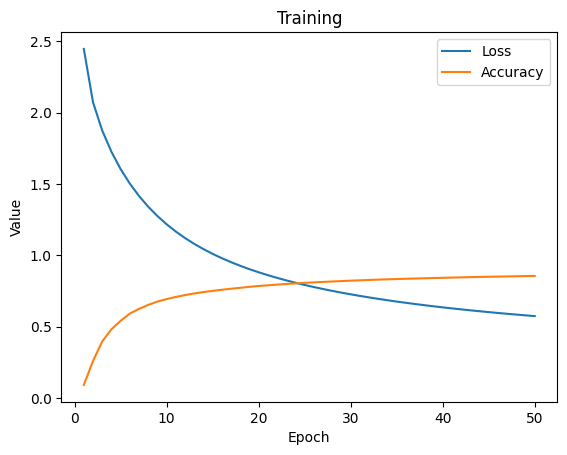

Accuracy  : 0.8668
Precision : 0.8658
Recall    : 0.8645
F1 Score  : 0.8642


In [44]:
# ---------------------------------------------------
# MNIST
# X = (features x samples)
# ---------------------------------------------------
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(60000, 784).T / 255.0 # (60000,28,28) -> (60000,784) -> (784,60000)
X_test = X_test.reshape(10000, 784).T / 255.0   # (10000,28,28) -> (10000,784) -> (784,10000)


# Training

params, loss, acc = train(
    X_train,
    y_train,
    layers=[784,128,64,10],
    epochs=50,
    lr=0.1,
    act1='tanh',
    act2='tanh'
)

plot_metrics(loss, acc)


# Testing

preds = evaluate(
    X_test,
    y_test,
    params,
    'tanh',
    'tanh'
)

acc, prec, rec, f1 = metrics(
    y_test,
    preds,
    10
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")